In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


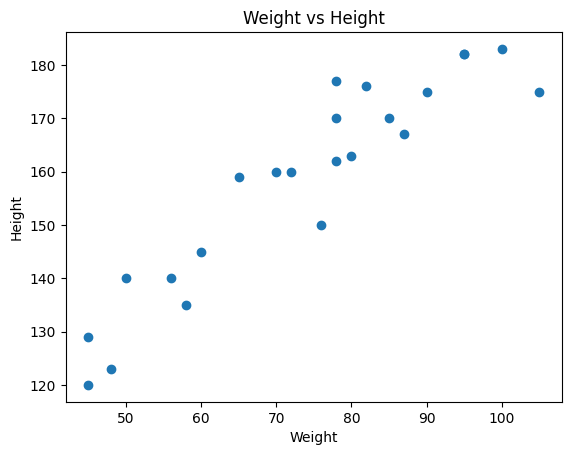

In [4]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs Height')
plt.show()

In [5]:
X = df[['Weight']]
y = df['Height']

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
X_train.shape

(18, 1)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


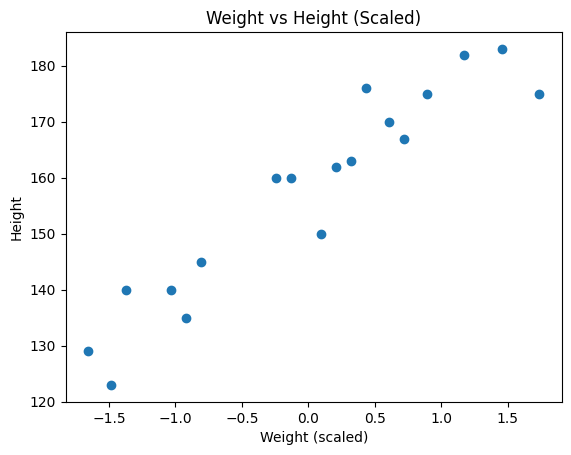

In [9]:
plt.scatter(X_train_scaled, y_train)
plt.xlabel('Weight (scaled)')
plt.ylabel('Height')
plt.title('Weight vs Height (Scaled)')
plt.show()


Mean Squared Error: 109.77592599051664
R^2 Score: 0.776986986042344


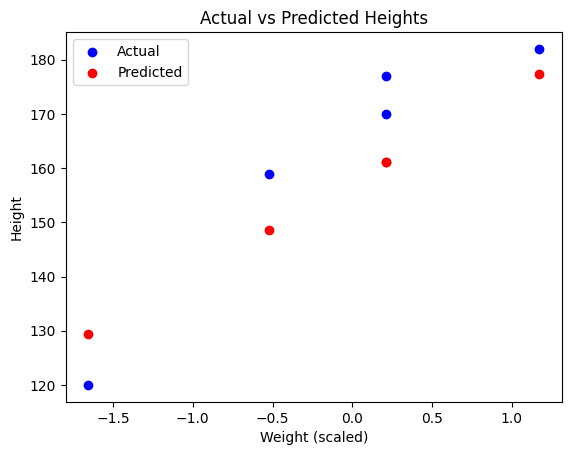

In [10]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')
plt.scatter(X_test_scaled, y_test, color='blue', label='Actual')
plt.scatter(X_test_scaled, y_pred, color='red', label='Predicted')
plt.xlabel('Weight (scaled)')
plt.ylabel('Height')
plt.title('Actual vs Predicted Heights')
plt.legend()
plt.show()

In [11]:
print(f'Regression Coefficients: {model.coef_}')
print(f'Intercept: {model.intercept_}')


Regression Coefficients: [17.03440872]
Intercept: 157.5


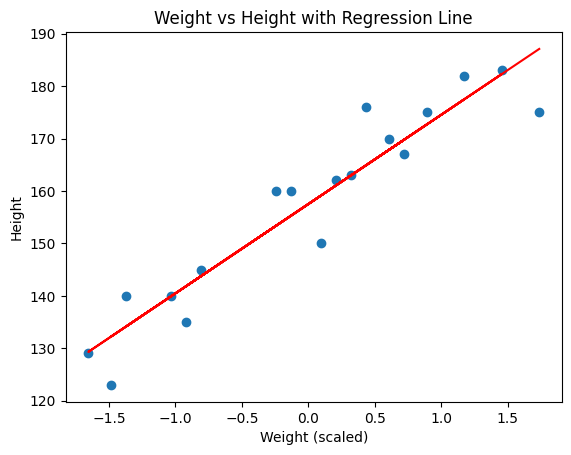

In [12]:
plt.scatter(X_train_scaled, y_train)
plt.plot(X_train_scaled, model.predict(X_train_scaled), color='red')
plt.xlabel('Weight (scaled)')
plt.ylabel('Height')
plt.title('Weight vs Height with Regression Line')
plt.show()


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')


Mean Absolute Error: 9.822657814519232
Mean Squared Error: 109.77592599051664
Root Mean Squared Error: 10.477400726827081


In [14]:
#Adjusted R^2
n = len(y_test)  # number of observations
p = X_test_scaled.shape[1]  # number of predictors
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'Adjusted R^2 Score: {adjusted_r2}')


Adjusted R^2 Score: 0.7026493147231252


In [15]:
scaled_weight = scaler.transform([[80]])  # Example weight
predicted_height = model.predict(scaled_weight)
print(f'Predicted height for weight 80: {predicted_height[0]}')

Predicted height for weight 80: 163.01076265919562


/Users/jeevan/Practice/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/var/folders/8m/5f5knf2d5sl5sy69ds7myszc0000gn/T/ipykernel_8411/2777769765.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde=True)


<Axes: xlabel='Height', ylabel='Density'>

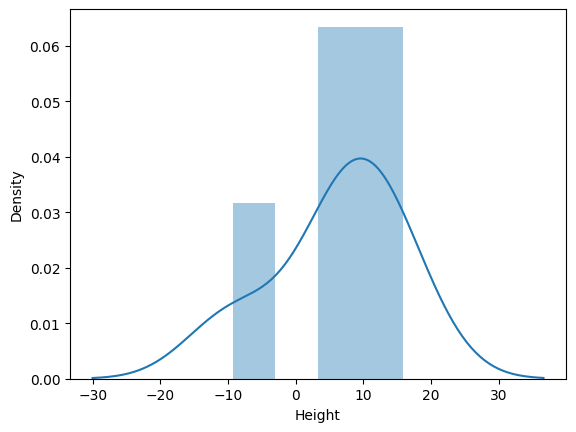

In [20]:
#Residuals
residuals = y_test - y_pred

import seaborn as sns
sns.distplot(residuals, kde=True)